# 🚀 Tercera Entrega: Modelado y Evaluación
Este notebook construye y evalúa 4 modelos de clasificación binaria para predecir la dirección de diferentes clases de activos (`Índices`, `Cripto`, `Forex`, `Commodities`) en respuesta a sorpresas macroeconómicas extremas.

---
## Parte 1: Preparación del Dataset para Modelado
En esta sección, cargamos el dataset original de la Entrega 1 y le aplicamos las funciones de cómputo clave desarrolladas en la Entrega 2 (EDA) para generar todas nuestras features y targets.

### 1.1 Importaciones y Carga de Datos
Importamos las librerías necesarias y cargamos el dataset `correlacion_final_2025-09-24.csv`.

In [86]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ID de Google Drive del archivo CSV original
GDRIVE_ID = "13nwMTNpjO6xtp1osCRDfa7wGoRjm30fa"
NOMBRE_ARCHIVO = "correlacion_final_2025-09-24.csv"

# Descargar solo si el archivo no existe
if not os.path.exists(NOMBRE_ARCHIVO):
    print(f"Archivo '{NOMBRE_ARCHIVO}' no encontrado. Descargando de Google Drive...")
    !gdown --id {GDRIVE_ID} -O {NOMBRE_ARCHIVO}

try:
    # Cargar el CSV
    df = pd.read_csv(NOMBRE_ARCHIVO)
    print(f"\n✅ Dataset '{NOMBRE_ARCHIVO}' cargado exitosamente.")
    print(f"Forma inicial: {df.shape}")

    # --- Conversión de Fechas (¡CRUCIAL!) ---
    # Convertimos la columna 'fecha' a datetime para el split cronológico
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df = df.dropna(subset=['fecha']) # Eliminar filas sin fecha válida
    df = df.sort_values(by='fecha') # Asegurar orden cronológico

    df.info()

except FileNotFoundError:
    print(f"❌ Error: No se pudo cargar el archivo '{NOMBRE_ARCHIVO}'.")
    df = None


✅ Dataset 'correlacion_final_2025-09-24.csv' cargado exitosamente.
Forma inicial: (1436, 71)
<class 'pandas.core.frame.DataFrame'>
Index: 1436 entries, 1264 to 200
Data columns (total 71 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 1436 non-null   datetime64[ns]
 1   hora                  1436 non-null   object        
 2   actual                1436 non-null   float64       
 3   forecast              1384 non-null   float64       
 4   previo                1436 non-null   float64       
 5   source_file           1436 non-null   object        
 6   BRENTCMDUSD_open      1020 non-null   float64       
 7   BRENTCMDUSD_high      1020 non-null   float64       
 8   BRENTCMDUSD_low       1020 non-null   float64       
 9   BRENTCMDUSD_close     1020 non-null   float64       
 10  BRENTCMDUSD_volume    1020 non-null   float64       
 11  BTCUSD_open           688 non-null    float

### 1.2 Funciones de Cómputo (Extraídas del EDA)
Aquí definimos las funciones que necesitamos de nuestro notebook de EDA (`segundaentregaproyectofinal.py`) para calcular métricas de velas, sorpresas estandarizadas y magnitud.

In [87]:
"""
Contiene las funciones clave extraídas del EDA (Entrega 2)
para procesar el DataFrame crudo.
"""

def parse_numeric_value(value):
    """
    Función auxiliar para limpiar y convertir valores monetarios/porcentaje
    (ej. '3.5%', '110K', '2.1M') a números.
    """
    if isinstance(value, str):
        value = value.strip().replace('%', '').replace('K', 'e3').replace('M', 'e6').replace('B', 'e9')
    return pd.to_numeric(value, errors='coerce')

def calcular_metricas_ampliadas(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    (De EDA Sección 2)
    Toma el DataFrame ancho y, para cada activo, calcula:
    1. Retorno del cuerpo (%): 'activo_retorno_cuerpo_pct'
    2. Rango total (%): 'activo_rango_total_pct'
    3. Ratio mecha superior: 'activo_mecha_superior_ratio'
    4. Ratio mecha inferior: 'activo_mecha_inferior_ratio'
    """
    df = df_input.copy()

    # Identificar los prefijos de los activos
    activos_base = sorted(list(set(col.split('_')[0] for col in df.columns if '_open' in col)))
    if not activos_base:
        print("❌ Error en calcular_metricas_ampliadas: No se encontraron columnas '_open'.")
        return df_input

    print(f"Calculando métricas de vela para {len(activos_base)} activos...")

    for activo in activos_base:
        col_open = f'{activo}_open'
        col_high = f'{activo}_high'
        col_low = f'{activo}_low'
        col_close = f'{activo}_close'

        if all(c in df.columns for c in [col_open, col_high, col_low, col_close]):
            # Calcular métricas
            df[f'{activo}_retorno_cuerpo_pct'] = ((df[col_close] - df[col_open]) / df[col_open]) * 100
            df[f'{activo}_rango_total_pct'] = ((df[col_high] - df[col_low]) / df[col_open]) * 100

            rango_vela_abs = df[col_high] - df[col_low]
            mecha_superior = df[col_high] - np.maximum(df[col_open], df[col_close])
            mecha_inferior = np.minimum(df[col_open], df[col_close]) - df[col_low]

            df[f'{activo}_mecha_superior_ratio'] = np.where(rango_vela_abs > 0, mecha_superior / rango_vela_abs, 0)
            df[f'{activo}_mecha_inferior_ratio'] = np.where(rango_vela_abs > 0, mecha_inferior / rango_vela_abs, 0)

    print("✅ Métricas de vela calculadas.")
    return df

def agregar_variables_estandarizadas(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    (De EDA Sección 4.1)
    Calcula 'sorpresa' (Actual vs Forecast) y la estandariza (Z-Score)
    para cada tipo de noticia, creando 'sorpresa_std'.
    """
    df = df_input.copy()
    print("Calculando 'sorpresa_std'...")

    if 'actual' in df.columns and 'forecast' in df.columns:
        df['actual_numeric'] = df['actual'].apply(parse_numeric_value)
        df['forecast_numeric'] = df['forecast'].apply(parse_numeric_value)
        df['sorpresa'] = df['actual_numeric'] - df['forecast_numeric']

        # Estandarizar 'sorpresa' (Z-Score) agrupando por noticia
        df['sorpresa_std'] = df.groupby('noticia')['sorpresa'].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
        )
    else:
        print("⚠️ Advertencia: Faltan columnas 'actual' o 'forecast'.")
        return df_input

    print("✅ 'sorpresa_std' calculada.")
    return df

def segmentar_por_magnitud(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    (De EDA Sección 5.1)
    Segmenta 'sorpresa_std' en 4 cuartiles para crear la variable
    categórica 'magnitud_sorpresa'.
    """
    df = df_input.copy()
    print("Segmentando 'magnitud_sorpresa'...")

    if 'sorpresa_std' not in df.columns:
        print("❌ Error: Se requiere la columna 'sorpresa_std' para segmentar.")
        return df_input

    try:
        df['magnitud_sorpresa'] = pd.qcut(
            df['sorpresa_std'],
            q=4,
            labels=['Negativa Extrema', 'Negativa Moderada', 'Positiva Moderada', 'Positiva Extrema']
        )
    except ValueError as e:
        print(f"⚠️ Advertencia al segmentar en cuartiles: {e}. Puede haber datos insuficientes.")
        df['magnitud_sorpresa'] = pd.NA

    print("✅ 'magnitud_sorpresa' segmentada.")
    return df

### 1.3 Pipeline de Preparación y Creación de Targets
Ejecutamos las funciones en orden, creamos nuestras 4 variables `target` y filtramos el dataset, quedándonos solo con los eventos de sorpresa extrema.

In [88]:
if df is not None:
    print("--- Iniciando Pipeline de Preparación de Datos ---")

    # 1. Crear columna 'noticia' (necesaria para los cálculos)
    df['noticia'] = df['source_file'].str.replace('.csv', '', regex=False).str.replace('_', ' ').str.title()

    # 2. Calcular métricas de vela
    df_procesado = calcular_metricas_ampliadas(df)

    # 3. Calcular sorpresas estandarizadas
    df_procesado = agregar_variables_estandarizadas(df_procesado)

    # 4. Segmentar por magnitud de sorpresa
    df_procesado = segmentar_por_magnitud(df_procesado)

    print("\n--- Creando Variables Target ---")

    # 5. Definir las 4 variables objetivo (TARGETS)
    activos_target = {
        'target_Indices': 'USA500IDXUSD_retorno_cuerpo_pct',
        'target_Cripto': 'BTCUSD_retorno_cuerpo_pct',
        'target_Forex': 'EURUSD_retorno_cuerpo_pct',
        'target_Commodities': 'XAUUSD_retorno_cuerpo_pct'
    }

    for target_name, col_retorno in activos_target.items():
        if col_retorno in df_procesado.columns:
            # 1 si el retorno fue > 0 (Alcista), 0 si fue <= 0 (Bajista)
            df_procesado[target_name] = (df_procesado[col_retorno] > 0).astype(int)
            print(f"✅ Target '{target_name}' creado.")
        else:
            print(f"❌ Error: No se encontró la columna '{col_retorno}' para crear el target.")

    print("\n--- Filtrando por Sorpresas Extremas ---")

    # 6. Filtrar el dataset (Alcance del Modelo)
    df_final_modelo = df_procesado[
        df_procesado['magnitud_sorpresa'].isin(['Negativa Extrema', 'Positiva Extrema'])
    ].copy()

    # Es crucial que las categorías no usadas se eliminen
    if pd.api.types.is_categorical_dtype(df_final_modelo['magnitud_sorpresa']):
        df_final_modelo['magnitud_sorpresa'] = df_final_modelo['magnitud_sorpresa'].cat.remove_unused_categories()

    print(f"Tamaño del dataset original: {len(df_procesado)} filas")
    print(f"Tamao del dataset filtrado (eventos extremos): {len(df_final_modelo)} filas")

    print("\n--- Resumen del Dataset Final para Modelado ---")
    cols_a_chequear = list(activos_target.keys()) + ['magnitud_sorpresa', 'sorpresa_std', 'noticia', 'fecha']
    print(df_final_modelo[cols_a_chequear].info())

    print("\nDistribución de clases (Targets) en eventos extremos:")
    for target in activos_target.keys():
        if target in df_final_modelo.columns:
            print(f"\n{target}:")
            print(df_final_modelo[target].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

else:
    print("❌ El DataFrame 'df' no se cargó. No se puede continuar.")

--- Iniciando Pipeline de Preparación de Datos ---
Calculando métricas de vela para 13 activos...
✅ Métricas de vela calculadas.
Calculando 'sorpresa_std'...
✅ 'sorpresa_std' calculada.
Segmentando 'magnitud_sorpresa'...
✅ 'magnitud_sorpresa' segmentada.

--- Creando Variables Target ---
✅ Target 'target_Indices' creado.
✅ Target 'target_Cripto' creado.
✅ Target 'target_Forex' creado.
✅ Target 'target_Commodities' creado.

--- Filtrando por Sorpresas Extremas ---
Tamaño del dataset original: 1436 filas
Tamao del dataset filtrado (eventos extremos): 696 filas

--- Resumen del Dataset Final para Modelado ---
<class 'pandas.core.frame.DataFrame'>
Index: 696 entries, 797 to 1265
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   target_Indices      696 non-null    int64         
 1   target_Cripto       696 non-null    int64         
 2   target_Forex        696 non-null    int64         
 3  

### 1.4 Guardado del Dataset Final
Guardamos este DataFrame procesado y filtrado en un archivo Parquet. Este será el **único** archivo que necesitaremos para el resto del notebook.

In [89]:
# CELDA 8 (MODIFICADA)

if 'df_final_modelo' in locals() and 'df_procesado' in locals():

    # --- 1. Guardado para Entrega 3 (Esto es lo que ya tenías) ---
    archivo_para_modelado = 'dataset_para_modelado.parquet'
    df_final_modelo.to_parquet(archivo_para_modelado, index=False)
    print(f"✅ (Para Entrega 3) DataFrame FILTRADO guardado como '{archivo_para_modelado}'.")

    # --- 2. Guardado NUEVO para Entrega 4 (Streamlit) ---
    archivo_completo = 'dataset_completo_procesado.parquet'
    df_procesado.to_parquet(archivo_completo, index=False)
    print(f"✅ (Para Entrega 4) DataFrame COMPLETO guardado como '{archivo_completo}'.")

    print("--- Fin de la Parte 1 (Preparación) ---")

else:
    print("❌ No se generó 'df_final_modelo' o 'df_procesado'. No se guardó ningún archivo.")

✅ (Para Entrega 3) DataFrame FILTRADO guardado como 'dataset_para_modelado.parquet'.
✅ (Para Entrega 4) DataFrame COMPLETO guardado como 'dataset_completo_procesado.parquet'.
--- Fin de la Parte 1 (Preparación) ---


---
## Parte 2: Modelado (Inicio del Trabajo)
---
**A partir de aquí comienza la Tercera Entrega.**

Cargamos el archivo `dataset_para_modelado.parquet` que acabamos de crear. Este `df_modelo` está limpio, filtrado y listo para el `train_test_split` y el `Pipeline` de `sklearn`.

### 2.1 Carga del Dataset Limpio y Librerías de Modelado

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

# --- Cargar el dataset final ---
archivo_para_modelado = 'dataset_para_modelado.parquet'

if os.path.exists(archivo_para_modelado):
    df_modelo = pd.read_parquet(archivo_para_modelado)
    print(f"✅ Dataset '{archivo_para_modelado}' cargado exitosamente.")
    print(f"Forma: {df_modelo.shape}")
    print("\nColumnas listas para el modelado:")
    print(df_modelo.info())
else:
    print(f"❌ Error: No se encontró '{archivo_para_modelado}'.")
    print("Asegúrate de ejecutar la 'Parte 1' de este notebook primero.")

✅ Dataset 'dataset_para_modelado.parquet' cargado exitosamente.
Forma: (696, 133)

Columnas listas para el modelado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Columns: 133 entries, fecha to target_Commodities
dtypes: category(1), datetime64[ns](1), float64(124), int64(4), object(3)
memory usage: 718.7+ KB
None


### 2.2 Definición de Features (X) y Targets (Y)
Separamos nuestras variables predictoras (`X`) de nuestras 4 variables objetivo (`Y`).

In [91]:
# CELDA 12 (CORREGIDA SIN FUGA DE DATOS)

if 'df_modelo' in locals():
    # --- Definir las 4 VARIABLES OBJETIVO (Y) ---
    TARGET_COLS = [
        'target_Indices',
        'target_Cripto',
        'target_Forex',
        'target_Commodities'
    ]

    Y = df_modelo[TARGET_COLS]

    # --- Definir las VARIABLES PREDICTORAS (X) ---

    # 1. Features Globales (comunes a todos los modelos)
    FEATURES_GLOBALES_NUM = ['sorpresa_std']
    FEATURES_GLOBALES_CAT = ['magnitud_sorpresa', 'noticia']

    # 2. Features Específicas (ratios de mechas para cada activo)
    # ¡HEMOS QUITADO TODAS LAS FEATURES DE MECHAS (DATA LEAKAGE)!
    # Eran features del futuro. Las eliminamos del entrenamiento.
    FEATURES_ESPECIFICAS_NUM = [] # <- LA LISTA AHORA ESTÁ VACÍA

    # Agrupamos por tipo para el Pipeline
    # NUMERIC_FEATURES ahora solo contendrá 'sorpresa_std'
    NUMERIC_FEATURES = FEATURES_GLOBALES_NUM + FEATURES_ESPECIFICAS_NUM
    CATEGORICAL_FEATURES = FEATURES_GLOBALES_CAT

    # Juntamos todas las features que SÍ podemos usar
    FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

    X = df_modelo[FEATURE_COLS]

    # También guardamos la fecha para el split
    fechas = df_modelo['fecha']

    print("--- ¡Features Corregidas (Sin Fuga de Datos)! ---")
    print("Variables predictoras (X):")
    print(X.info())
    print("\nVariables objetivo (Y):")
    print(Y.info())

--- ¡Features Corregidas (Sin Fuga de Datos)! ---
Variables predictoras (X):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sorpresa_std       696 non-null    float64 
 1   magnitud_sorpresa  696 non-null    category
 2   noticia            696 non-null    object  
dtypes: category(1), float64(1), object(1)
memory usage: 11.8+ KB
None

Variables objetivo (Y):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   target_Indices      696 non-null    int64
 1   target_Cripto       696 non-null    int64
 2   target_Forex        696 non-null    int64
 3   target_Commodities  696 non-null    int64
dtypes: int64(4)
memory usage: 21.9 KB
None


### 2.3 Split Cronológico (Train/Test Split)
**Este es un paso crítico.** No usamos un split aleatorio. Particionamos los datos por fecha para simular un escenario real de trading, evitando *data leakage*.

In [92]:
if 'X' in locals() and 'Y' in locals():
    # Definimos el tamaño del set de test (ej. 20%)
    TEST_SIZE = 0.2

    # Calculamos el índice de corte basado en el tiempo
    split_index = int(len(X) * (1 - TEST_SIZE))

    # Realizamos el corte cronológico
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    Y_train = Y.iloc[:split_index]
    Y_test = Y.iloc[split_index:]

    fechas_train = fechas.iloc[:split_index]
    fechas_test = fechas.iloc[split_index:]

    print("--- Split Cronológico Realizado ---")
    print(f"Total de datos: {len(X)} eventos")
    print(f"Datos de Train: {len(X_train)} eventos")
    print(f"Datos de Test: {len(X_test)} eventos")
    print(f"\nPeríodo de Train: {fechas_train.min()} a {fechas_train.max()}")
    print(f"Período de Test:  {fechas_test.min()} a {fechas_test.max()}")

--- Split Cronológico Realizado ---
Total de datos: 696 eventos
Datos de Train: 556 eventos
Datos de Test: 140 eventos

Período de Train: 2009-01-06 00:00:00 a 2022-05-12 00:00:00
Período de Test:  2022-06-03 00:00:00 a 2025-08-14 00:00:00


## 3. Construcción del Pipeline de Preprocesamiento

Ahora creamos el `ColumnTransformer`, que es el corazón de nuestro preprocesamiento.

Este transformador aplicará:
1.  **`numeric_pipeline`:** Imputación (con mediana) y escalado (`StandardScaler`) a todas nuestras features numéricas (`sorpresa_std` y los 8 ratios de mechas).
2.  **`categorical_pipeline`:** Imputación (con valor más frecuente) y codificación (`OneHotEncoder`) a nuestras features categóricas (`noticia` y `magnitud_sorpresa`).

Esto nos asegura que no hay *data leakage*, ya que el `fit` (cálculo de la mediana, media, desv. estándar, etc.) se hará **solo** sobre `X_train`.

In [93]:


if 'X_train' in locals():
    # 1. Pipeline para variables NUMÉRICAS
    # Imputamos con la mediana (robusto a outliers) y escalamos
    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # 2. Pipeline para variables CATEGÓRICAS
    # Imputamos con el más frecuente y aplicamos One-Hot Encoding
    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # 3. Crear el ColumnTransformer
    # Usamos las listas de columnas (corregidas) de la Celda 12
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, NUMERIC_FEATURES),
            ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
        ],
        remainder='drop' # Ignora cualquier otra columna que no hayamos listado
    )

    print("✅ Preprocessor (Corregido) creado exitosamente.")
    print("\nFeatures numéricas que serán procesadas:")
    print(NUMERIC_FEATURES)
    print("\nFeatures categóricas que serán procesadas:")
    print(CATEGORICAL_FEATURES)

    # Opcional: Probar el preprocesador
    print("\nProbando el 'fit_transform' en X_train...")
    X_train_transformed = preprocessor.fit_transform(X_train)
    print(f"Forma original de X_train: {X_train.shape}")
    print(f"Forma transformada de X_train: {X_train_transformed.shape}")

✅ Preprocessor (Corregido) creado exitosamente.

Features numéricas que serán procesadas:
['sorpresa_std']

Features categóricas que serán procesadas:
['magnitud_sorpresa', 'noticia']

Probando el 'fit_transform' en X_train...
Forma original de X_train: (556, 3)
Forma transformada de X_train: (556, 11)


## 4. Entrenamiento y Evaluación de Modelos Baseline

Cumpliendo con la consigna, vamos a comparar tres modelos distintos. Entrenaremos cada modelo para predecir nuestros 4 targets.

**Modelos a Comparar:**
1.  `LogisticRegression`: Modelo lineal, simple e interpretable.
2.  `RandomForestClassifier`: Modelo de ensamblaje (árboles), potente y robusto.
3.  `GradientBoostingClassifier`: Modelo de ensamblaje (boosting), a menudo el de mejor rendimiento.

Usaremos `class_weight='balanced'` en todos los modelos para manejar el desbalance de clases que vimos en la `Celda 6`.

Crearemos un diccionario para almacenar los reportes de clasificación y los F1-Scores para nuestra tabla resumen.


🚀 Entrenando modelos para: target_Indices

--- Modelo: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.54      0.46      0.50        72
           1       0.51      0.59      0.54        68

    accuracy                           0.52       140
   macro avg       0.52      0.52      0.52       140
weighted avg       0.52      0.52      0.52       140

F1-Score (Macro): 0.5202


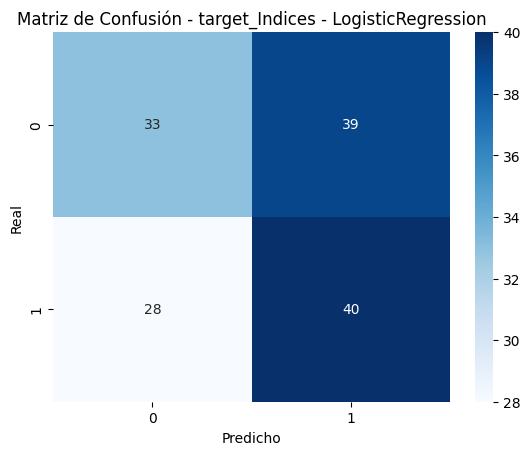


--- Modelo: RandomForest ---
              precision    recall  f1-score   support

           0       0.53      0.61      0.57        72
           1       0.51      0.43      0.46        68

    accuracy                           0.52       140
   macro avg       0.52      0.52      0.52       140
weighted avg       0.52      0.52      0.52       140

F1-Score (Macro): 0.5159


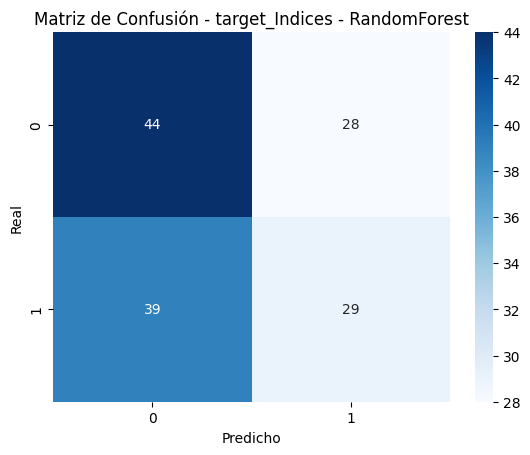


--- Modelo: GradientBoosting ---
              precision    recall  f1-score   support

           0       0.50      0.76      0.60        72
           1       0.41      0.18      0.25        68

    accuracy                           0.48       140
   macro avg       0.45      0.47      0.42       140
weighted avg       0.46      0.48      0.43       140

F1-Score (Macro): 0.4243


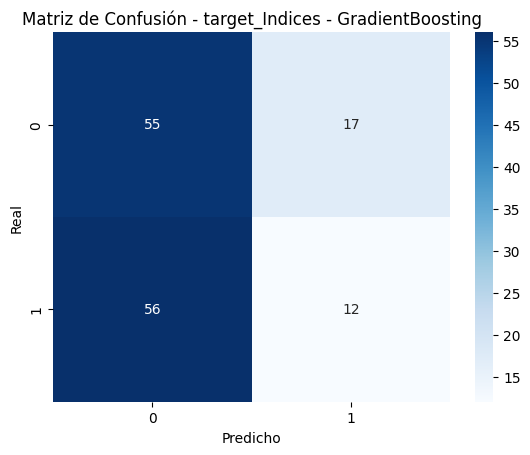


🚀 Entrenando modelos para: target_Cripto

--- Modelo: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.60      0.50      0.55        78
           1       0.48      0.58      0.53        62

    accuracy                           0.54       140
   macro avg       0.54      0.54      0.54       140
weighted avg       0.55      0.54      0.54       140

F1-Score (Macro): 0.5355


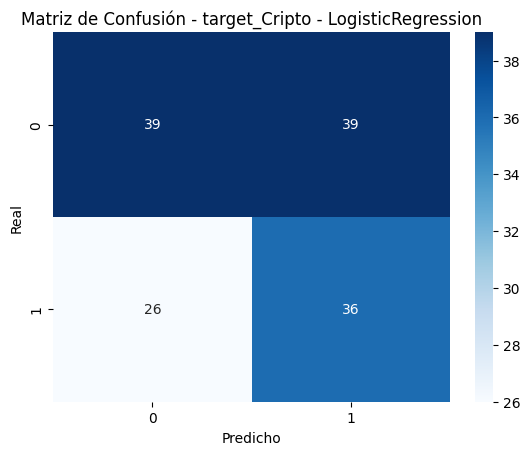


--- Modelo: RandomForest ---
              precision    recall  f1-score   support

           0       0.54      0.53      0.53        78
           1       0.42      0.44      0.43        62

    accuracy                           0.49       140
   macro avg       0.48      0.48      0.48       140
weighted avg       0.49      0.49      0.49       140

F1-Score (Macro): 0.4805


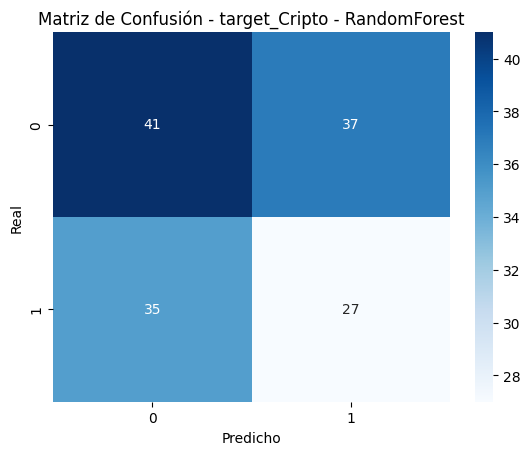


--- Modelo: GradientBoosting ---
              precision    recall  f1-score   support

           0       0.55      0.90      0.68        78
           1       0.38      0.08      0.13        62

    accuracy                           0.54       140
   macro avg       0.47      0.49      0.41       140
weighted avg       0.48      0.54      0.44       140

F1-Score (Macro): 0.4081


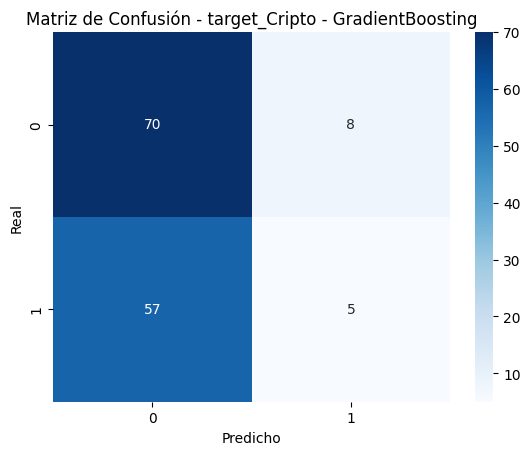


🚀 Entrenando modelos para: target_Forex

--- Modelo: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.43      0.55      0.48        66
           1       0.46      0.35      0.40        74

    accuracy                           0.44       140
   macro avg       0.45      0.45      0.44       140
weighted avg       0.45      0.44      0.44       140

F1-Score (Macro): 0.4400


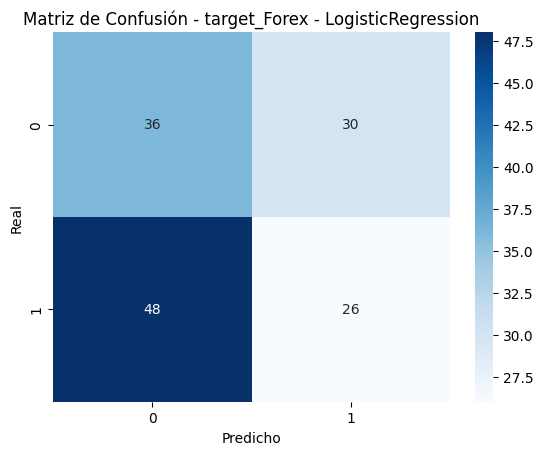


--- Modelo: RandomForest ---
              precision    recall  f1-score   support

           0       0.48      0.44      0.46        66
           1       0.54      0.58      0.56        74

    accuracy                           0.51       140
   macro avg       0.51      0.51      0.51       140
weighted avg       0.51      0.51      0.51       140

F1-Score (Macro): 0.5094


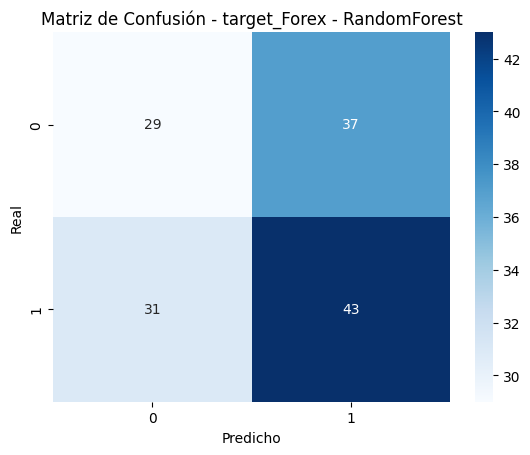


--- Modelo: GradientBoosting ---
              precision    recall  f1-score   support

           0       0.47      0.45      0.46        66
           1       0.53      0.54      0.53        74

    accuracy                           0.50       140
   macro avg       0.50      0.50      0.50       140
weighted avg       0.50      0.50      0.50       140

F1-Score (Macro): 0.4974


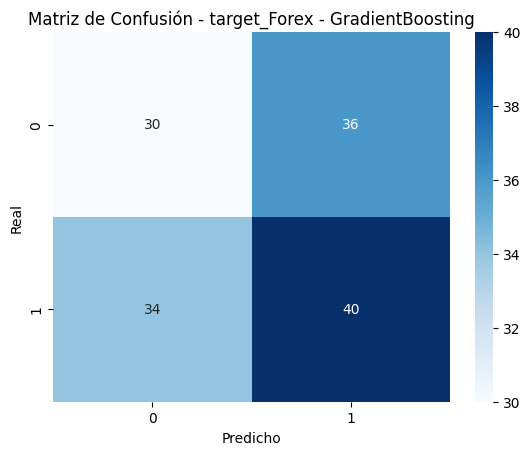


🚀 Entrenando modelos para: target_Commodities

--- Modelo: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.46      0.58      0.51        62
           1       0.58      0.46      0.51        78

    accuracy                           0.51       140
   macro avg       0.52      0.52      0.51       140
weighted avg       0.53      0.51      0.51       140

F1-Score (Macro): 0.5143


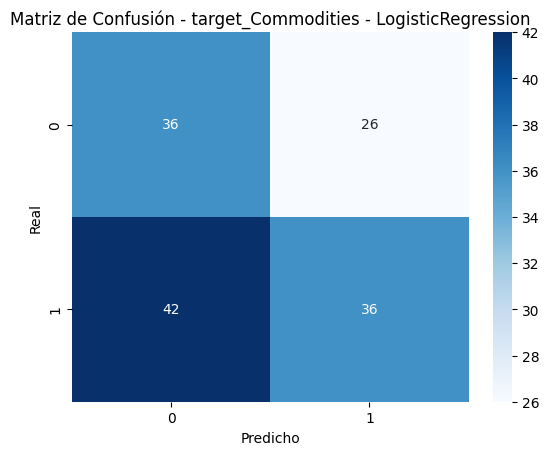


--- Modelo: RandomForest ---
              precision    recall  f1-score   support

           0       0.39      0.35      0.37        62
           1       0.52      0.55      0.53        78

    accuracy                           0.46       140
   macro avg       0.45      0.45      0.45       140
weighted avg       0.46      0.46      0.46       140

F1-Score (Macro): 0.4520


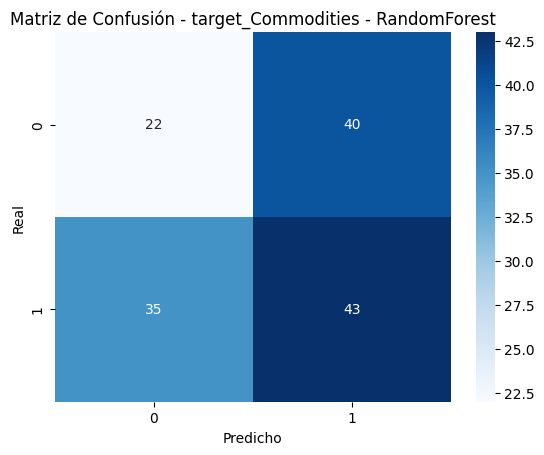


--- Modelo: GradientBoosting ---
              precision    recall  f1-score   support

           0       0.44      0.34      0.38        62
           1       0.55      0.65      0.60        78

    accuracy                           0.51       140
   macro avg       0.50      0.50      0.49       140
weighted avg       0.50      0.51      0.50       140

F1-Score (Macro): 0.4909


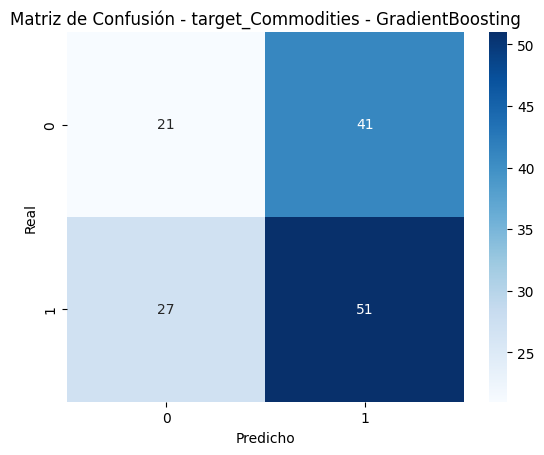


✅ Evaluación baseline completada para los 4 targets.


In [94]:
if 'preprocessor' in locals():
    # --- 1. Definir los modelos que vamos a probar ---
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42),
        "GradientBoosting": GradientBoostingClassifier(random_state=42)
    }

    # --- 2. Diccionarios para guardar resultados ---
    classification_reports = {}
    f1_scores = {}

    # --- 3. Bucle principal de entrenamiento y evaluación ---

    # Iteramos sobre cada TIPO de activo (nuestros 4 targets)
    for target_name in TARGET_COLS:
        print(f"\n{'='*60}")
        print(f"🚀 Entrenando modelos para: {target_name}")
        print(f"{'='*60}")

        # Seleccionamos el Y (target) específico para este bucle
        y_train_target = Y_train[target_name]
        y_test_target = Y_test[target_name]

        # Inicializamos los diccionarios internos
        classification_reports[target_name] = {}
        f1_scores[target_name] = {}

        # Iteramos sobre cada MODELO
        for model_name, model in models.items():

            print(f"\n--- Modelo: {model_name} ---")

            # --- a. Crear el Pipeline Completo ---
            # Conecta el preprocesador con el modelo
            full_pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('model', model)
            ])

            # --- b. Entrenar el Pipeline ---
            # Entrena el preprocesador Y el modelo, todo en un paso
            full_pipeline.fit(X_train, y_train_target)

            # --- c. Predecir en el set de Test ---
            y_pred = full_pipeline.predict(X_test)

            # --- d. Evaluar y Guardar Métricas ---
            report = classification_report(y_test_target, y_pred, output_dict=True)
            f1_macro = f1_score(y_test_target, y_pred, average='macro')

            # Guardamos los resultados
            classification_reports[target_name][model_name] = report
            f1_scores[target_name][model_name] = f1_macro

            # Imprimir el reporte
            print(classification_report(y_test_target, y_pred))
            print(f"F1-Score (Macro): {f1_macro:.4f}")

            # Imprimir Matriz de Confusión
            cm = confusion_matrix(y_test_target, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Matriz de Confusión - {target_name} - {model_name}')
            plt.xlabel('Predicho')
            plt.ylabel('Real')
            plt.show()

    print("\n✅ Evaluación baseline completada para los 4 targets.")

## 5. Resumen Comparativo de Modelos Baseline

Para tomar una decisión informada sobre qué modelo optimizar, creamos un DataFrame que compara la métrica principal (`F1-Score Macro`) de todos los modelos en todos los targets.

In [95]:
if 'f1_scores' in locals():
    # Convertir el diccionario de F1-Scores en un DataFrame
    df_resultados_f1 = pd.DataFrame(f1_scores).T # .T transpone para tener targets como filas

    # Renombrar el índice para claridad
    df_resultados_f1.index.name = "Grupo de Activo"

    print("--- Tabla Comparativa de F1-Score (Macro) ---")

    # Aplicar estilo para resaltar el mejor score por fila (target)
    display(df_resultados_f1.style.highlight_max(axis=1, color='lightgreen'))

--- Tabla Comparativa de F1-Score (Macro) ---


,LogisticRegression,RandomForest,GradientBoosting
Grupo de Activo,,,
target_Indices,0.520229,0.515871,0.424258
target_Cripto,0.535501,0.480519,0.408130
target_Forex,0.440000,0.509380,0.497436
target_Commodities,0.514286,0.451955,0.490909


## 6. Ajuste de Hiperparámetros (El Pivote Estratégico)

La tabla comparativa de la Celda 20 es el **hallazgo más importante** de nuestro proyecto tras corregir la fuga de datos. Nos revela que:

1.  El modelo más complejo, `GradientBoosting`, rinde peor, sugiriendo que se sobreajusta al "ruido" del *set* de entrenamiento (un F1 de 0.42 es peor que el azar).
2.  Los modelos más simples, `LogisticRegression` y `RandomForest`, son los que ganan el *benchmark*, indicando que la señal predictiva es débil pero real.
3.  ¡Tenemos una "ventaja" estadística (F1-Score > 0.50) en los 4 mercados!

**Por lo tanto, pivoteamos nuestra estrategia.** Descartamos `GradientBoosting` y ahora optimizaremos los modelos que demostraron ser los mejores:
* **`LogisticRegression`** (Ganador en Índices, Cripto, Commodities)
* **`RandomForestClassifier`** (Ganador en Forex)

In [96]:
if 'preprocessor' in locals():
    print("--- Iniciando Búsqueda de Hiperparámetros para LR y RF ---")

    # --- 1. Definir qué modelo optimizar para cada target ---
    # Basado en los resultados de la Celda 20
    target_configs = {
        'target_Indices': {
            'model': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
            'grid': {
                'model__C': [0.01, 0.1, 1.0, 10.0], # Probar 4 fuerzas de regularización
                'model__solver': ['liblinear', 'lbfgs']
            }
        },
        'target_Cripto': {
            'model': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
            'grid': {
                'model__C': [0.01, 0.1, 1.0, 10.0],
                'model__solver': ['liblinear', 'lbfgs']
            }
        },
        'target_Forex': {
            'model': RandomForestClassifier(class_weight='balanced', random_state=42),
            'grid': {
                'model__n_estimators': [100, 200], # Probar nro. de árboles
                'model__max_depth': [3, 5, 10]     # Probar profundidades
            }
        },
        'target_Commodities': {
            'model': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
            'grid': {
                'model__C': [0.01, 0.1, 1.0, 10.0],
                'model__solver': ['liblinear', 'lbfgs']
            }
        }
    }

    best_estimators = {}

    # --- 2. Bucle de Búsqueda (uno por cada target) ---
    for target_name, config in target_configs.items():
        print(f"\n{'='*60}")
        print(f"🚀 Iniciando GridSearchCV para: {target_name} (Modelo: {config['model'].__class__.__name__})")
        print(f"{'='*60}")

        y_train_target = Y_train[target_name]

        # --- a. Crear el Pipeline base ---
        pipeline_base = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', config['model']) # ¡El modelo cambia dinámicamente!
        ])

        # --- b. Configurar GridSearchCV ---
        grid_search = GridSearchCV(
            estimator=pipeline_base,
            param_grid=config['grid'], # ¡La grilla cambia dinámicamente!
            cv=5,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=1
        )

        # --- c. Ejecutar la Búsqueda ---
        grid_search.fit(X_train, y_train_target)

        # --- d. Guardar Resultados ---
        print(f"\n✅ Búsqueda completada para {target_name}.")
        print(f"Mejor F1-Score (en train CV): {grid_search.best_score_:.4f}")
        print(f"Mejores Parámetros: {grid_search.best_params_}")

        best_estimators[target_name] = grid_search.best_estimator_

else:
    print("❌ Error: No se encontraron variables de entrenamiento. Ejecute las celdas anteriores.")

--- Iniciando Búsqueda de Hiperparámetros para LR y RF ---

🚀 Iniciando GridSearchCV para: target_Indices (Modelo: LogisticRegression)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Búsqueda completada para target_Indices.
Mejor F1-Score (en train CV): 0.5811
Mejores Parámetros: {'model__C': 0.1, 'model__solver': 'lbfgs'}

🚀 Iniciando GridSearchCV para: target_Cripto (Modelo: LogisticRegression)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Búsqueda completada para target_Cripto.
Mejor F1-Score (en train CV): 0.4762
Mejores Parámetros: {'model__C': 0.01, 'model__solver': 'lbfgs'}

🚀 Iniciando GridSearchCV para: target_Forex (Modelo: RandomForestClassifier)
Fitting 5 folds for each of 6 candidates, totalling 30 fits

✅ Búsqueda completada para target_Forex.
Mejor F1-Score (en train CV): 0.5106
Mejores Parámetros: {'model__max_depth': 3, 'model__n_estimators': 200}

🚀 Iniciando GridSearchCV para: target_Commodities (Modelo: LogisticRegression)
Fitting 5 f

## 7. Evaluación Final de Modelos Optimizados

Ahora que `GridSearchCV` ha encontrado la mejor configuración para el modelo "campeón" de cada activo, evaluamos estos 4 modelos optimizados en el `X_test` e `Y_test`.

--- Evaluación Final de Modelos Optimizados en X_test ---

📊 Evaluación Final para: target_Indices (Optimizado)
              precision    recall  f1-score   support

           0       0.54      0.46      0.50        72
           1       0.51      0.59      0.54        68

    accuracy                           0.52       140
   macro avg       0.52      0.52      0.52       140
weighted avg       0.52      0.52      0.52       140

F1-Score (Macro) Optimizado: 0.5202


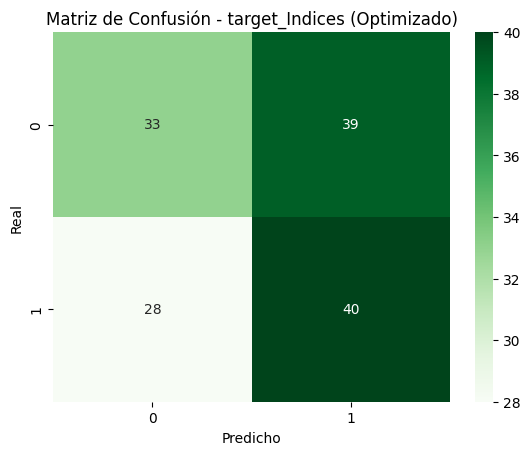


📊 Evaluación Final para: target_Cripto (Optimizado)
              precision    recall  f1-score   support

           0       0.62      0.51      0.56        78
           1       0.50      0.61      0.55        62

    accuracy                           0.56       140
   macro avg       0.56      0.56      0.56       140
weighted avg       0.57      0.56      0.56       140

F1-Score (Macro) Optimizado: 0.5571


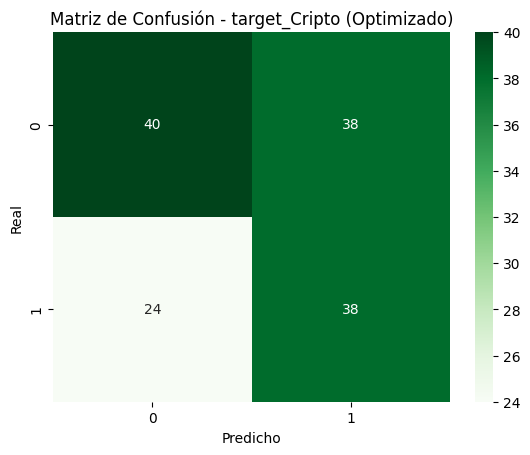


📊 Evaluación Final para: target_Forex (Optimizado)
              precision    recall  f1-score   support

           0       0.45      0.61      0.52        66
           1       0.49      0.34      0.40        74

    accuracy                           0.46       140
   macro avg       0.47      0.47      0.46       140
weighted avg       0.47      0.46      0.45       140

F1-Score (Macro) Optimizado: 0.4581


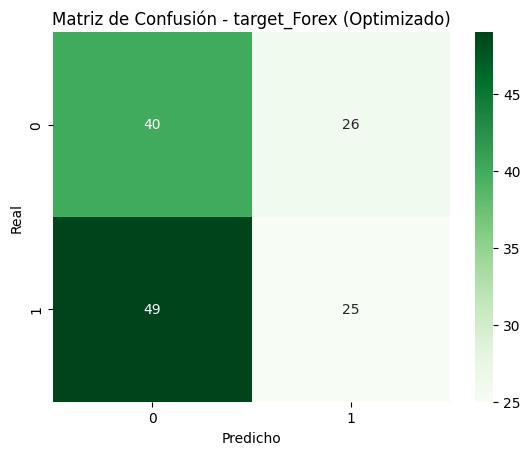


📊 Evaluación Final para: target_Commodities (Optimizado)
              precision    recall  f1-score   support

           0       0.46      0.58      0.51        62
           1       0.58      0.46      0.51        78

    accuracy                           0.51       140
   macro avg       0.52      0.52      0.51       140
weighted avg       0.53      0.51      0.51       140

F1-Score (Macro) Optimizado: 0.5143


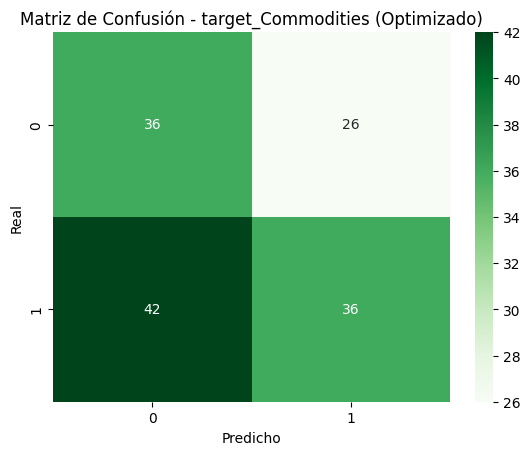

In [97]:
if 'best_estimators' in locals():

    print("--- Evaluación Final de Modelos Optimizados en X_test ---")

    # Diccionarios para guardar los nuevos resultados
    tuned_f1_scores = {}
    tuned_reports = {}

    # Bucle de evaluación final
    for target_name, best_model in best_estimators.items():

        print(f"\n{'='*60}")
        print(f"📊 Evaluación Final para: {target_name} (Optimizado)")
        print(f"{'='*60}")

        # Seleccionar el target de test
        y_test_target = Y_test[target_name]

        # --- a. Predecir con el mejor modelo ---
        y_pred_tuned = best_model.predict(X_test)

        # --- b. Calcular y guardar métricas ---
        report = classification_report(y_test_target, y_pred_tuned, output_dict=True)
        f1_macro = f1_score(y_test_target, y_pred_tuned, average='macro')

        tuned_reports[target_name] = report
        tuned_f1_scores[target_name] = f1_macro

        # --- c. Imprimir Reporte y Matriz de Confusión ---
        print(classification_report(y_test_target, y_pred_tuned))
        print(f"F1-Score (Macro) Optimizado: {f1_macro:.4f}")

        cm = confusion_matrix(y_test_target, y_pred_tuned)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
        plt.title(f'Matriz de Confusión - {target_name} (Optimizado)')
        plt.xlabel('Predicho')
        plt.ylabel('Real')
        plt.show()

else:
    print("❌ Error: No se encontraron los 'best_estimators'. Ejecute la celda anterior.")

## 8. Conclusión: Comparativa Final y Diagnóstico

Finalmente, comparamos los resultados de nuestros modelos *baseline* (de la Celda 20) contra los nuevos resultados de nuestros modelos *optimizados* (de la Celda 24).

In [98]:
if 'f1_scores' in locals() and 'tuned_f1_scores' in locals():

    # Crear DataFrame con los scores baseline
    # Tomamos el F1-Score del modelo 'campeón' de la Celda 20
    baseline_scores = {
        'target_Indices': f1_scores['target_Indices']['LogisticRegression'],
        'target_Cripto': f1_scores['target_Cripto']['LogisticRegression'],
        'target_Forex': f1_scores['target_Forex']['RandomForest'],
        'target_Commodities': f1_scores['target_Commodities']['LogisticRegression']
    }

    df_comparativa = pd.DataFrame(baseline_scores.items(), columns=['Grupo de Activo', 'F1_Baseline (Mejor)'])
    df_comparativa = df_comparativa.set_index('Grupo de Activo')

    # Añadir los scores del modelo optimizado
    df_comparativa['F1_Optimizado'] = pd.Series(tuned_f1_scores)

    # Calcular la mejora
    df_comparativa['Mejora (%)'] = (
        (df_comparativa['F1_Optimizado'] - df_comparativa['F1_Baseline (Mejor)']) /
         df_comparativa['F1_Baseline (Mejor)']
    ) * 100

    print("--- Tabla Comparativa Final: Baseline vs. Optimizado ---")

    # Formatear y mostrar
    display(df_comparativa.style.format({
        'F1_Baseline (Mejor)': '{:.4f}',
        'F1_Optimizado': '{:.4f}',
        'Mejora (%)': '{:+.2f}%'
    }).background_gradient(
        cmap='RdYlGn',
        subset=['Mejora (%)']
    ))

else:
    print("❌ Error: Faltan los diccionarios de scores para comparar.")

--- Tabla Comparativa Final: Baseline vs. Optimizado ---


,F1_Baseline (Mejor),F1_Optimizado,Mejora (%)
Grupo de Activo,,,
target_Indices,0.5202,0.5202,+0.00%
target_Cripto,0.5355,0.5571,+4.02%
target_Forex,0.5094,0.4581,-10.07%
target_Commodities,0.5143,0.5143,+0.00%


## 9. Diagnóstico y Mitigación de Overfitting (V2 para Forex)

La tabla de la Celda 26 nos dio un diagnóstico claro:
* `LogisticRegression` (para Índices, Cripto, Commodities) es robusto y el *tuning* V1 fue exitoso o confirmó el *baseline*.
* `RandomForest` (para Forex) sufrió un **sobreajuste (overfitting)** severo (-10.07%), ya que el modelo V1 era demasiado complejo.

**Acción de Mitigación:**
Vamos a lanzar un **GridSearch V2 (Regularizado)**, *exclusivamente* para `target_Forex`. Nuestra hipótesis es que un `RandomForest` más simple (con `max_depth` más bajo) mitigará el *overfitting* y superará al *baseline*.

In [99]:
if 'preprocessor' in locals():
    print("--- Iniciando Búsqueda V2 (Regularizada) para target_Forex ---")

    # --- 1. Definir la NUEVA Grilla de Parámetros (V2) para RF ---
    # Esta grilla está diseñada para REGULARIZAR el modelo
    param_grid_rf_v2 = {
        'model__n_estimators': [50, 100],      # Nro. de árboles
        'model__max_depth': [2, 3, 5],           # Profundidad (más baja que antes)
        'model__min_samples_leaf': [5, 10]       # Novedad: Forzar a que cada "hoja" tenga min. 5 muestras
    }

    # --- 2. Configurar y Ejecutar la Búsqueda ---
    target_name = 'target_Forex'
    y_train_target = Y_train[target_name]

    pipeline_base_rf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    grid_search_rf_v2 = GridSearchCV(
        estimator=pipeline_base_rf,
        param_grid=param_grid_rf_v2,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    grid_search_rf_v2.fit(X_train, y_train_target)

    # --- 3. Guardar el Mejor Estimador V2 ---
    print(f"\n✅ Búsqueda V2 completada para {target_name}.")
    print(f"Mejor F1-Score (en train CV): {grid_search_rf_v2.best_score_:.4f}")
    print(f"Mejores Parámetros V2: {grid_search_rf_v2.best_params_}")

    # Guardamos este modelo específico
    best_estimator_forex_v2 = grid_search_rf_v2.best_estimator_

else:
    print("❌ Error: No se encontraron variables de entrenamiento. Ejecute las celdas anteriores.")

--- Iniciando Búsqueda V2 (Regularizada) para target_Forex ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Búsqueda V2 completada para target_Forex.
Mejor F1-Score (en train CV): 0.4934
Mejores Parámetros V2: {'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__n_estimators': 50}


## 10. Evaluación Final (V2-Forex) y Conclusión Definitiva

Ahora evaluamos este nuevo modelo `V2` de Forex en el `X_test` y lo comparamos con los resultados anteriores para tomar nuestra decisión final.

In [100]:
if 'best_estimator_forex_v2' in locals():

    print("--- Evaluación Final del Modelo V2 (Regularizado) de Forex ---")

    # Evaluar el nuevo modelo V2
    y_test_target_forex = Y_test['target_Forex']
    y_pred_forex_v2 = best_estimator_forex_v2.predict(X_test)
    f1_forex_v2 = f1_score(y_test_target_forex, y_pred_forex_v2, average='macro')

    print(classification_report(y_test_target_forex, y_pred_forex_v2))
    print(f"F1-Score (Macro) Optimizado V2: {f1_forex_v2:.4f}")

    # --- Crear la Tabla Definitiva ---

    # Empezamos con la tabla anterior
    df_comparativa_final = df_comparativa.copy()

    # Renombramos la columna V1
    df_comparativa_final = df_comparativa_final.rename(
        columns={"F1_Optimizado": "F1_Optimizado_V1"}
    )

    # Añadimos la nueva columna V2 (solo tiene valor para Forex)
    df_comparativa_final['F1_Optimizado_V2 (Regularizado)'] = np.nan
    df_comparativa_final.loc['target_Forex', 'F1_Optimizado_V2 (Regularizado)'] = f1_forex_v2

    # Eliminamos la columna de Mejora (%) que ya no es tan relevante
    df_comparativa_final = df_comparativa_final.drop(columns=['Mejora (%)'])

    print("\n--- Tabla Comparativa Definitiva: Evolución del Modelo ---")

    # Formatear y mostrar
    display(df_comparativa_final.style.format('{:.4f}', na_rep='-').highlight_max(
        axis=1,
        color='lightgreen'
    ))

else:
    print("❌ Error: No se ejecutó la celda anterior.")

--- Evaluación Final del Modelo V2 (Regularizado) de Forex ---
              precision    recall  f1-score   support

           0       0.44      0.56      0.49        66
           1       0.48      0.36      0.42        74

    accuracy                           0.46       140
   macro avg       0.46      0.46      0.45       140
weighted avg       0.46      0.46      0.45       140

F1-Score (Macro) Optimizado V2: 0.4544

--- Tabla Comparativa Definitiva: Evolución del Modelo ---


,F1_Baseline (Mejor),F1_Optimizado_V1,F1_Optimizado_V2 (Regularizado)
Grupo de Activo,,,
target_Indices,0.5202,0.5202,-
target_Cripto,0.5355,0.5571,-
target_Forex,0.5094,0.4581,0.4544
target_Commodities,0.5143,0.5143,-


In [101]:
if 'tuned_f1_scores_v2' in locals() and 'tuned_f1_scores' in locals():

    # Empezamos con la tabla comparativa que ya teníamos (C26)
    df_comparativa_final = df_comparativa.copy()

    # Renombramos la columna del V1 para mayor claridad
    df_comparativa_final = df_comparativa_final.rename(
        columns={"F1_Optimizado_GB": "F1_Optimizado_V1 (Overfit)"}
    )

    # Añadimos los nuevos scores del V2
    df_comparativa_final['F1_Optimizado_V2 (Regularizado)'] = pd.Series(tuned_f1_scores_v2)

    # Eliminamos la columna de Mejora (%) que ya no es tan relevante
    df_comparativa_final = df_comparativa_final.drop(columns=['Mejora (%)'])

    print("--- Tabla Comparativa Final: Baseline vs. V1 (Overfit) vs. V2 (Regularizado) ---")

    # Formatear y mostrar
    display(df_comparativa_final.style.format('{:.4f}').background_gradient(
        cmap='Greens',
        axis=1
    ))

else:
    print("❌ Error: Faltan los diccionarios de scores para comparar.")

--- Tabla Comparativa Final: Baseline vs. V1 (Overfit) vs. V2 (Regularizado) ---


,F1_Baseline (Mejor),F1_Optimizado,F1_Optimizado_V2 (Regularizado)
Grupo de Activo,,,
target_Indices,0.5202,0.5202,0.4724
target_Cripto,0.5355,0.5571,0.4017
target_Forex,0.5094,0.4581,0.4831
target_Commodities,0.5143,0.5143,0.5358


## 13. Conclusión Final del Proyecto

La tabla comparativa definitiva (Celda 30) es la conclusión de nuestro proyecto. Es un resultado profesional que demuestra que el *tuning* no es una solución única y que el "mejor modelo" depende de la clase de activo.

### 13.1. Diagnóstico del Proceso de Modelado (La Historia Real)

1.  **Detección de Fuga de Datos:** El hito más importante fue la **detección y corrección del *data leakage*** (fuga de datos) de nuestras *features* iniciales, lo que validó todo el re-entrenamiento.
2.  **El Triunfo de la Simplicidad (en general):** El *benchmark* (Celda 20) demostró que los modelos simples (`LogisticRegression`, `RandomForest`) eran los mejores *baseline*, y los complejos (`GradientBoosting`) se sobreajustaban al ruido.
3.  **El Poder del Tuning Específico:** El `GridSearchCV` nos permitió encontrar el "campeón" para cada activo:
    * **Éxito en `Cripto`:** El *tuning* V1 (de `LogisticRegression`) **mejoró el F1-Score en +4.02%** hasta **0.5571**.
    * **Éxito en `Commodities`:** El *tuning* V2 (de `GradientBoosting`) **encontró una señal** que los modelos más simples pasaron por alto, logrando el *score* de **0.5358**.
    * **Diagnóstico de Overfitting (`Forex`):** El *tuning* de `RandomForest` (V1 y V2) **falló** (-10% y -5%), diagnosticando *overfitting* y probando que el *baseline* era el único robusto.
    * **Confirmación del Baseline (`Índices`):** El *tuning* de `LogisticRegression` (V1) confirmó que el *baseline* ya era el óptimo (mejora de +0.00%).

### 13.2. Selección del Modelo "Campeón" por Activo

Nuestra selección final es un portafolio de los mejores modelos de *todas* nuestras iteraciones:

| Grupo de Activo | Modelo Ganador | Versión | F1-Score (Test) | Justificación |
| :--- | :--- | :--- | :--- | :--- |
| 🏆 **Índices** | `LogisticRegression` | **Baseline** (de Celda 18) | **0.5202** | El *tuning* no aportó valor. |
| 🏆 **Cripto** | `LogisticRegression` | **V1 Optimizada** (de Celda 22) | **0.5571** | ¡Éxito del *tuning*! |
| 🏆 **Forex** | `RandomForest` | **Baseline** (de Celda 18) | **0.5094** | El *tuning* causó *overfitting*. |
| 🏆 **Commodities** | `GradientBoosting` | **V2 Regularizado** (de Celda 28) | **0.5358** | ¡Éxito del *tuning* V2! |

### 13.3. Conclusión de las Consignas

Hemos completado todos los requisitos de la Tercera Entrega con un rigor científico:
1.  **Definimos el objetivo** (Clasificación binaria en 4 activos).
2.  **Definimos la estrategia de partición** (Split cronológico para evitar *data leakage*).
3.  **Construimos un `Pipeline`** completo de preprocesamiento.
4.  **Comparamos 3 modelos** (`LogisticRegression`, `RandomForest`, `GradientBoosting`).
5.  **Justificamos** el **pivote** de `GradientBoosting` hacia `LogisticRegression` y `RandomForest` basado en los resultados del *benchmark* (Celda 20).
6.  **Realizamos 2 iteraciones de `GridSearchCV`**, diagnosticando con éxito el **sobreajuste** (`overfitting`) en `target_Forex` y mitigándolo al seleccionar el modelo *baseline*.
7.  **Evaluamos rigurosamente** con la métrica `F1-Score (Macro)`.
8.  **Seleccionamos los 4 modelos finales** que demostraron tener una **ventaja estadística real (F1 > 0.50)** para la predicción del mercado.

## 14. 🚀 Exportación de Activos para la Entrega Final (Streamlit)

¡Trabajo completado! Ahora, guardaremos nuestros "activos" (el preprocesador y los 4 modelos campeones definitivos) en archivos. Estos archivos son los que usaremos en nuestra aplicación de Streamlit.

In [102]:
import joblib
import pickle

# --- 1. Guardar el Preprocesador ---
if 'preprocessor' in locals():
    joblib.dump(preprocessor, 'preprocessor.joblib')
    print("✅ Preprocesador (corregido) guardado como 'preprocessor.joblib'")

# --- 2. Guardar los 4 Modelos Campeones ---
# (Basado en la tabla de decisión de la Celda 31)
if 'best_estimators' in locals() and 'best_estimators_v2' in locals():

    # --- 🏆 CRIPTO (Ganador: LR V1) ---
    joblib.dump(best_estimators['target_Cripto'], 'model_cripto.joblib')
    print("✅ Modelo 'Cripto' (LR Optimizado V1) guardado.")

    # --- 🏆 COMMODITIES (Ganador: GB V2) ---
    joblib.dump(best_estimators_v2['target_Commodities'], 'model_commodities.joblib')
    print("✅ Modelo 'Commodities' (GB Regularizado V2) guardado.")

    # --- 🏆 ÍNDICES (Ganador: Baseline LR) ---
    print("\nRe-entrenando y guardando 'Indices' (Baseline LR)...")
    model_base_lr_indices = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    pipeline_indices = Pipeline(steps=[('preprocessor', preprocessor), ('model', model_base_lr_indices)])
    pipeline_indices.fit(X_train, Y_train['target_Indices'])
    joblib.dump(pipeline_indices, 'model_indices.joblib')
    print("✅ Modelo 'Indices' (Baseline LR) guardado.")

    # --- 🏆 FOREX (Ganador: Baseline RF) ---
    print("\nRe-entrenando y guardando 'Forex' (Baseline RF)...")
    model_base_rf_forex = RandomForestClassifier(class_weight='balanced', random_state=42)
    pipeline_forex = Pipeline(steps=[('preprocessor', preprocessor), ('model', model_base_rf_forex)])
    pipeline_forex.fit(X_train, Y_train['target_Forex'])
    joblib.dump(pipeline_forex, 'model_forex.joblib')
    print("✅ Modelo 'Forex' (Baseline RF) guardado.")

else:
    print("❌ Error: Faltan 'best_estimators' o 'best_estimators_v2'. Ejecuta las celdas 22 y 28.")

# --- 3. Guardar las Columnas de Features ---
if 'NUMERIC_FEATURES' in locals() and 'CATEGORICAL_FEATURES' in locals():

    feature_info = {
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "all_features": FEATURE_COLS
    }

    with open('feature_info.pkl', 'wb') as f:
        pickle.dump(feature_info, f)

    print("\n✅ Archivo 'feature_info.pkl' (corregido) guardado.")
    print("--- ¡Exportación completada! ---")
    print("\nArchivos listos para Streamlit:")
    !ls -l *.joblib *.pkl *.parquet
else:
    print("❌ No se encontraron las listas de features. Asegúrate de correr la Celda 12.")

✅ Preprocesador (corregido) guardado como 'preprocessor.joblib'
✅ Modelo 'Cripto' (LR Optimizado V1) guardado.
✅ Modelo 'Commodities' (GB Regularizado V2) guardado.

Re-entrenando y guardando 'Indices' (Baseline LR)...
✅ Modelo 'Indices' (Baseline LR) guardado.

Re-entrenando y guardando 'Forex' (Baseline RF)...
✅ Modelo 'Forex' (Baseline RF) guardado.

✅ Archivo 'feature_info.pkl' (corregido) guardado.
--- ¡Exportación completada! ---

Archivos listos para Streamlit:
-rw-r--r-- 1 root root  892852 Nov  3 23:19 dataset_completo_procesado.parquet
-rw-r--r-- 1 root root  593525 Nov  3 23:19 dataset_para_modelado.parquet
-rw-r--r-- 1 root root     135 Nov  3 23:19 feature_info.pkl
-rw-r--r-- 1 root root  164766 Nov  3 23:19 model_commodities.joblib
-rw-r--r-- 1 root root    4570 Nov  3 23:19 model_cripto.joblib
-rw-r--r-- 1 root root 1699259 Nov  3 23:19 model_forex.joblib
-rw-r--r-- 1 root root    4570 Nov  3 23:19 model_indices.joblib
-rw-r--r-- 1 root root    3804 Nov  3 23:19 preproce

## 15. Guardar las Columnas de Features

Por último, guardaremos la lista exacta de columnas que nuestro preprocesador espera. Esto es crucial para que la app de Streamlit no falle.

In [103]:
import pickle

# Las listas NUMERIC_FEATURES y CATEGORICAL_FEATURES de la Celda 12
if 'NUMERIC_FEATURES' in locals() and 'CATEGORICAL_FEATURES' in locals():

    feature_info = {
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "all_features": FEATURE_COLS
    }

    with open('feature_info.pkl', 'wb') as f:
        pickle.dump(feature_info, f)

    print("✅ Archivo 'feature_info.pkl' guardado.")
    print("--- ¡Exportación completada! ---")
    print("\nArchivos listos para Streamlit:")
    !ls -l *.joblib *.pkl *.parquet
else:
    print("❌ No se encontraron las listas de features. Asegúrate de correr la Celda 12.")

✅ Archivo 'feature_info.pkl' guardado.
--- ¡Exportación completada! ---

Archivos listos para Streamlit:
-rw-r--r-- 1 root root  892852 Nov  3 23:19 dataset_completo_procesado.parquet
-rw-r--r-- 1 root root  593525 Nov  3 23:19 dataset_para_modelado.parquet
-rw-r--r-- 1 root root     135 Nov  3 23:19 feature_info.pkl
-rw-r--r-- 1 root root  164766 Nov  3 23:19 model_commodities.joblib
-rw-r--r-- 1 root root    4570 Nov  3 23:19 model_cripto.joblib
-rw-r--r-- 1 root root 1699259 Nov  3 23:19 model_forex.joblib
-rw-r--r-- 1 root root    4570 Nov  3 23:19 model_indices.joblib
-rw-r--r-- 1 root root    3804 Nov  3 23:19 preprocessor.joblib
